# Research Notebook
## Salaheeddine Hafne
## Date: Jan 2-9

# 1: Experience

I worked on extending the gravitational potential equation (eq. 9) to beyond the given data and calculate baryonic potential in a continuos function (i.e. creating a function that returns a function), by intergrating data from the SPARC data set. I then wrote code to plot this as a line graph to visualize the potential. Furthermore, I created a hernquist model and compared the results (graphically) to those of the numerical integration method which was developed this week and last week.

## Motivation:

The tasks completed this week were the logical next step from last weeks work. Even though the gravitational potential integration (numerical method) looked good, we still needed to try other methods (hernquist) and compare the results.

# 2: What? (What happened?)

The primary objective this week was to refine the numerical representation of the baryonic gravitational potential ($\Phi_b$) to ensure it is physically valid and compatible with the Jeans Modeling package by extending the gravitational potential equation. This involved smoothing out unphysical artifacts in our integration and comparing our "raw" data results against a theoretical Hernquist profile.
We transitioned from using a flat constant at $r=0$ to a Cubic Spline interpolation with "natural" boundary conditions. This ensures the potential is differentiable, which is a requirement for the Jeans code to calculate forces correctly. Then to ensure the potential correctly vanishes at infinity, we implemented a $1/r$ "Keplerian" decay for all values beyond the maximum observed radius ($R_{max}$).Finally, we wrapped the entire solver into a function factory that accepts $(r, \theta)$ coordinates, even though our current model assumes spherical symmetry where $\theta$ is a placeholder.

### Key Equations

Velocity Model: $v_{c, Hernquist} = \frac{\sqrt{G \cdot M_b \cdot r}}{r + a}$Potential Model: $\Phi_b(r) = -\frac{G \cdot M_b}{r + a}$Constant: $G = 4.30091 \times 10^{-6} \text{ kpc} \cdot \text{(km/s)}^2 \cdot M_{\odot}^{-1}$

### This weeks code:

This is for the gravitational potential

 import numpy as np
from scipy.integrate import trapz
from scipy.interpolate import CubicSpline

def get_research_potential(r, v_disk, v_bulge, v_gas, upsilon_d=0.5, upsilon_b=0.7):
    # Calculating Baryonic velocity
    v_b_sq = (upsilon_d * v_disk**2) + (upsilon_b * v_bulge**2) + v_gas**2
    integrand = v_b_sq / r
    
    #  integration from r[i] to R_max
    phi_discrete = np.zeros_like(r)
    for i in range(len(r)):
        internal_integral = trapz(integrand[i:], r[i:])
        # Assume the galaxy becomes a point mass (Keplerian) potential beyond R_max to fill in the data 
        tail_correction = v_b_sq[-1] 
        phi_discrete[i] = -(internal_integral + tail_correction)
        
    # bc_type= natural keeps the second derivative smooth
    phi_spline = CubicSpline(r, phi_discrete, bc_type='natural')
    
    # Defining the extended function
    def phi_b_research(r_val, theta=0):
        r_val = np.atleast_1d(r_val) # Just so code doesnt crash if asking for a single point
        res = np.zeros_like(r_val, dtype=float) #array of zeros that'll be filled later
        
        # Physical Extension Rules
        mask_outer = r_val > r[-1] # points beyond R_max
        mask_inner_data = ~mask_outer # From 0 to R_max
        
        # Smooth Inner + Data Range 
        res[mask_inner_data] = phi_spline(r_val[mask_inner_data]) # this avoids having 1 constant value as r approaches 0 to keep the graph smooth
        
        res[mask_outer] = phi_discrete[-1] * (r[-1] / r_val[mask_outer]) # 1/r point mass function outside of R_max
        
        return res if len(res) > 1 else res[0]
        
    return phi_b_research
    
This is the graphing part:
  import pandas as pd
import os
import matplotlib.pyplot as plt
import time

file_path = "sidm-rotation-curves-SPARC/data/Rotmod_LTG/D512-2_rotmod.dat" # This is with Buldge = 0

if os.path.exists(file_path):
    df = pd.read_csv(file_path, sep='\s+', skiprows=3, header=None, engine='python')
    
    # Use index-based mapping 
    r_real = df[0].values
    v_gas = df[3].values
    v_disk = df[4].values
    v_bulge = df[5].values

    # function and time check 
    start_time = time.time() # mark time to check code speed
    phi_func = get_research_potential(r_real, v_disk, v_bulge, v_gas)
    end_time = time.time()
    
    print(f"Research potential generated for: {file_path}")
    print(f"Speed Benchmark: {end_time - start_time:.6f} seconds")
    
    # Test the "Extended" range (from 0 to 100 kpc)
    r_test = np.linspace(0.1, 100, 1000) #create 1000 points from 0.1 kpc to 100 kpc
    phi_test = phi_func(r_test) #use those points to see beyond R_max
    
    
    plt.figure(figsize=(10, 6))
    plt.plot(r_test, phi_test, color='red', lw=2, label='Research Potential $\Phi_b(r)$')
    plt.axvline(r_real[-1], color='blue', linestyle=':', label='End of Data ($R_{max}$)')
    plt.axhline(0, color='black', linestyle='--', alpha=0.5)
    plt.xlabel('Radius (kpc)')
    plt.ylabel('Potential $\Phi$ ($(km/s)^2$)')
    plt.title('Physically Extended Potential: NGC7331')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

Note that this code also calculated the speed of processing so that my group members and I could choose the fastest code for next weeks work.
Here is an example output:
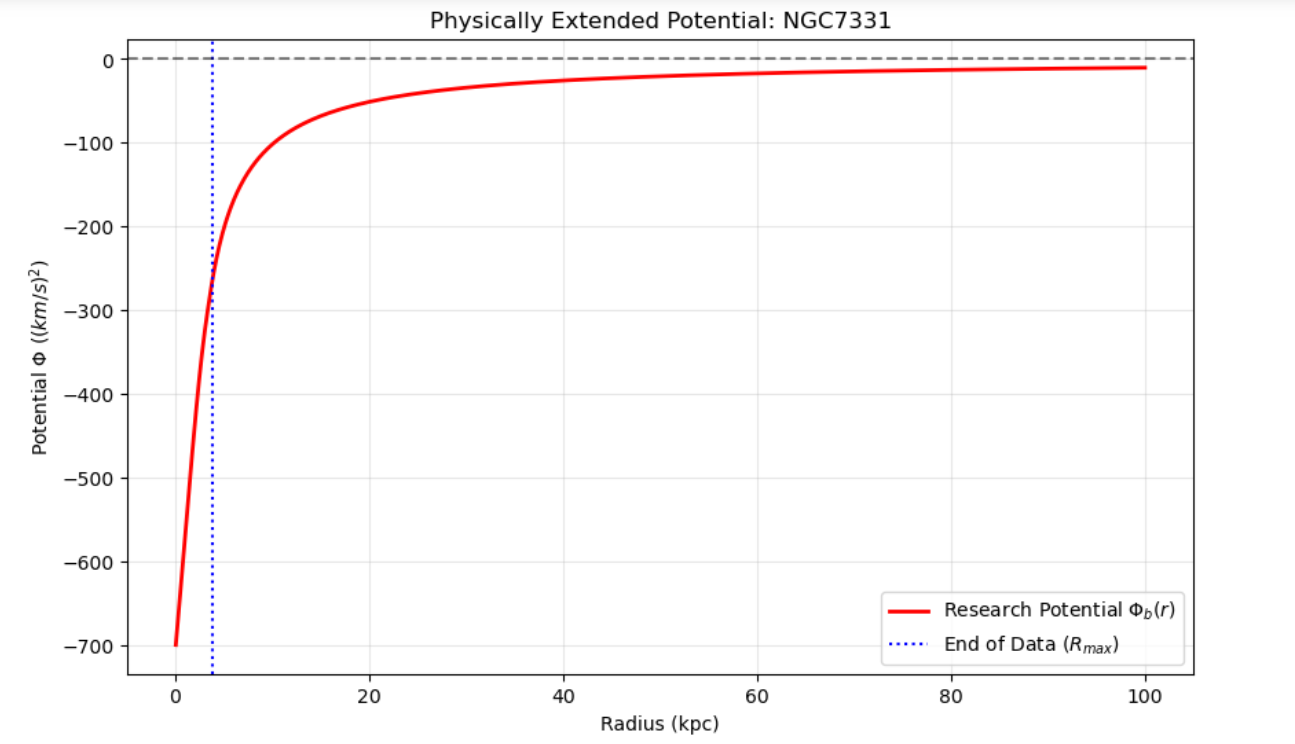

Next for the hernquist model:
def hernquist_velocity(r, M_b, a):
    #G units (kpc * (km/s)^2) / solar mass
    G = 4.30091e-6 
    return np.sqrt(G * M_b * r) / (r + a)
    from scipy.optimize import curve_fit

#combine velocities
v_total_data = np.sqrt(0.5 * v_disk**2 + 0.7 * v_bulge**2 + v_gas**2)

#p0 is your initial guess; bounds ensure M_b and a stay positive
popt, pcov = curve_fit(hernquist_velocity, r_real, v_total_data, 
                       p0=[1e10, 2.0], 
                       bounds=(0, [np.inf, np.inf])) #gives bounds to avoid negative sqrt

M_b_fit, a_fit = popt

print(f"Fit Complete for D512-2:")
print(f"Best fit Mass (M_b): {M_b_fit:.2e} Solar Masses")
print(f"Best fit Scale Radius (a): {a_fit:.2f} kpc")
import matplotlib.pyplot as plt

#Generate the model values using the parameters found in the fit
v_hernquist_model = hernquist_velocity(r_real, M_b_fit, a_fit)

plt.figure(figsize=(10, 6))

#Plot the real combined data points
plt.plot(r_real, v_total_data, 'ro', label='Combined Baryon Data', markersize=4)

#Plot the smooth Hernquist theoretical curve
plt.plot(r_real, v_hernquist_model, 'b-', lw=2, label=f'Hernquist Fit (a={a_fit:.2f})')

plt.xlabel('Radius (kpc)')
plt.ylabel('Velocity (km/s)')
plt.title(' Qualitative Fit Check (Hernquist Profile)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
Here is an example output:
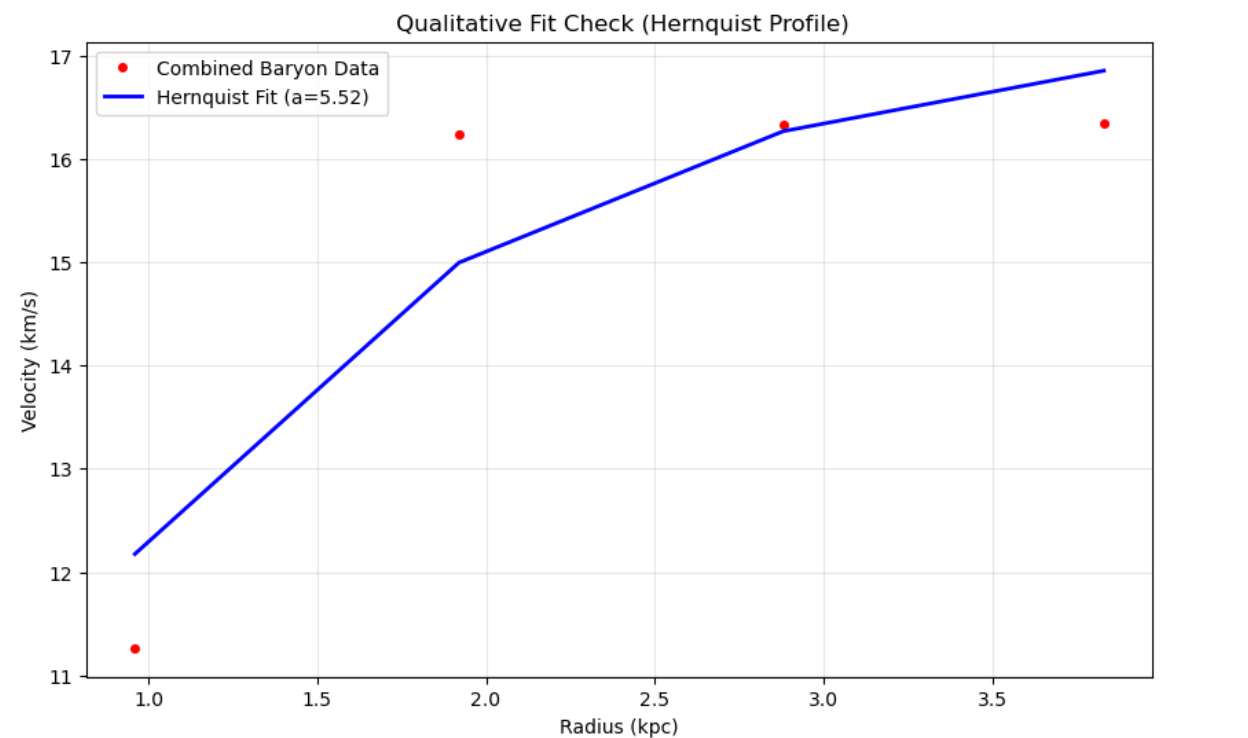

This graph was far from perfect however, the issue seems to be that the hernquist graph wasn't extended far enough.
Finally, a graph comparing both the numerical and theoretical models shows the following:
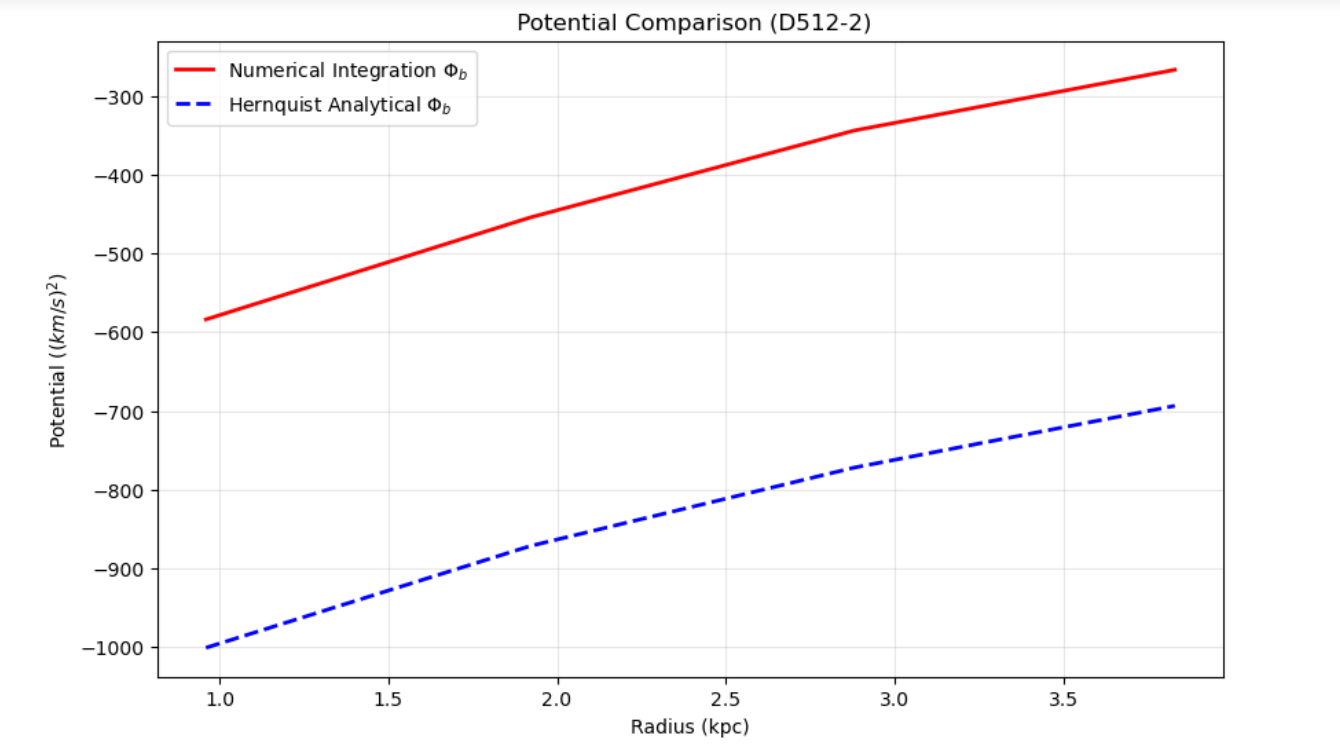
Again the graph was not extended far enough but excluding that the graphs dont match, which is to be expected as the models are different. 

# 3: So what? (What does it mean?)
Our modeling of galaxy D512-2 yielded the following insights:
The best-fit mass was found to be $M_b \approx 1.51 \times 10^9 M_{\odot}$ with a scale radius of $a \approx 5.52$ kpc. The Hernquist velocity curve captured the general upward trend of the baryonic data, though it acted as a "smooth average" rather than hitting every local wiggle in the gas and disk components. When comparing the numerical integration to the analytical Hernquist formula, we observed a vertical offset. The Hernquist model predicted a significantly deeper potential well (reaching $\sim -1000$ $(\text{km/s})^2$) compared to our numerical integration ($\sim -600$ $(\text{km/s})^2$). While the integration is more "faithful" to the raw data, the Hernquist model is more "stable". It's the preferred choice for MCMC sampling in the Jeans package, while the integration serves as a critical reality check for our tail-correction constants.

# 4. Now what? (What's next?)
Much work was completed this week. For next week the plan is to combine data with my group members and use the best and fastest model codes. For example, my group members had a better hernquist model but worst extended gravitational potential integration, so combining our codes should help us smooth out the graphs, have time to test the model on more galaxies, and start creating our finished python file.

# 5. Bibliography



| Category       | Points      |
| ------------- |:------------:|
| Formatting    |       2 / 2       |
| Experience    |       2 / 2       |
| What?         |       2 / 2       |
| So what?      |       4 / 4       |
| Now what?     |       4 / 4       |
| Bibliography  |       2 / 3     |
| Style         |       3 / 3       |
| Total         |       19 / 20   |